# **Exploratory Data Analysis**

The aim of this script is to first analyse the dataset from kaggle by exploring its `.csv` files.

To do this, we will make an spaghetti plot, where we will plot injury vs Day per athlete.

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. Define the relative path to your file
# Navigate up from 'Codes' and down into 'Datasets'
file_path = '../Dataset/week_approach_maskedID_timeseries.csv'

# Load the data
df = pd.read_csv(file_path)

# Quick check to see if it loaded correctly
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42798 entries, 0 to 42797
Data columns (total 72 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   nr. sessions                                   42798 non-null  float64
 1   nr. rest days                                  42798 non-null  float64
 2   total kms                                      42798 non-null  float64
 3   max km one day                                 42798 non-null  float64
 4   total km Z3-Z4-Z5-T1-T2                        42798 non-null  float64
 5   nr. tough sessions (effort in Z5, T1 or T2)    42798 non-null  float64
 6   nr. days with interval session                 42798 non-null  float64
 7   total km Z3-4                                  42798 non-null  float64
 8   max km Z3-4 one day                            42798 non-null  float64
 9   total km Z5-T1-T2                              427

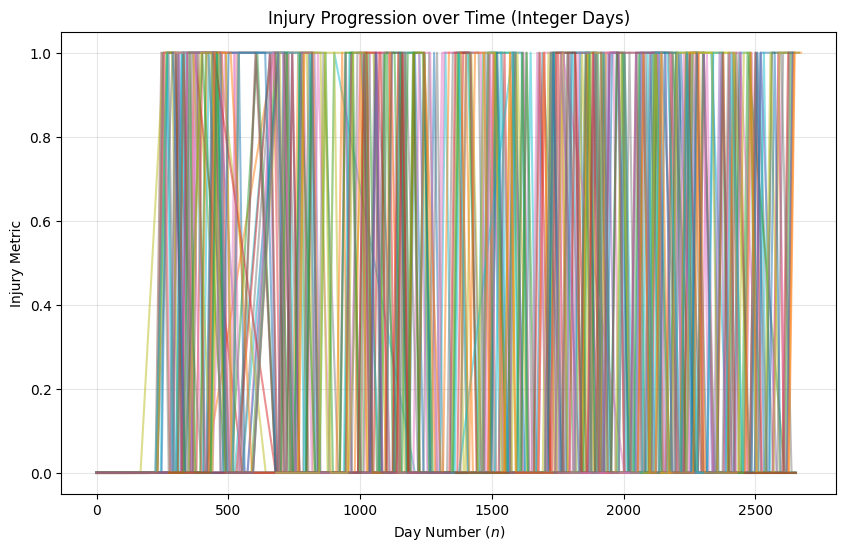

In [4]:
# Sort to ensure lines connect in the right order
df = df.sort_values(by=['Athlete ID', 'Date'])

plt.figure(figsize=(10, 6))

# Plot each ID
for athlete_id, group in df.groupby('Athlete ID'):
    plt.plot(group['Date'], group['injury'], alpha=0.5, label=athlete_id)

plt.title('Injury Progression over Time (Integer Days)')
plt.xlabel('Day Number ($n$)')
plt.ylabel('Injury Metric')
plt.grid(True, alpha=0.3)
plt.show()

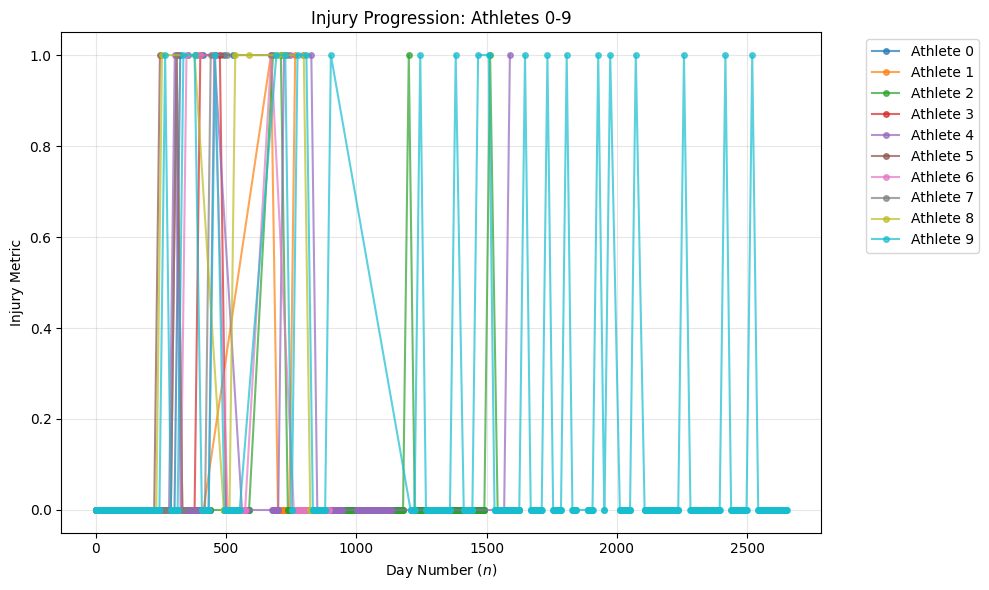

In [5]:
# Filter for Athletes 0-9
# If IDs are integers:
target_ids = list(range(10)) 

df_filtered = df[df['Athlete ID'].isin(target_ids)].copy()

# 3. Sort and Plot
df_filtered = df_filtered.sort_values(by=['Athlete ID', 'Date'])

plt.figure(figsize=(10, 6))

for athlete_id, group in df_filtered.groupby('Athlete ID'):
    plt.plot(group['Date'], group['injury'], marker='o', markersize=4, alpha=0.7, label=f'Athlete {athlete_id}')

plt.title('Injury Progression: Athletes 0-9')
plt.xlabel('Day Number ($n$)')
plt.ylabel('Injury Metric')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()